## Mounting data and importing code

In [48]:
import os

test_folder = data_dirs["test"]
print("Test folder exists:", os.path.exists(test_folder))
print("Number of test images:", len(os.listdir(test_folder) if os.path.exists(test_folder) else []))


Test folder exists: True
Number of test images: 350


In [49]:
%matplotlib inline

In [ ]:
import os
import shutil
import sys
from importlib import reload
from os.path import join

# Define local paths
BASE_DIR = "C:/Users/ashok/Desktop/Barco"
CODE_DIR = os.path.join(BASE_DIR, "code")
PROJECT_NAME = "Barco_project"  
PROJECT_PATH = os.path.join(BASE_DIR, PROJECT_NAME)
DATASET_PATH = "C:/Users/ashok/Desktop/Barco"


if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)

# Copying all code files from CODE_DIR to PROJECT_PATH
if os.path.exists(CODE_DIR):
    code_files = os.listdir(CODE_DIR)
    for file_name in code_files:
        src_file = os.path.join(CODE_DIR, file_name)
        dst_file = os.path.join(PROJECT_PATH, file_name)
        if os.path.isfile(src_file):
            shutil.copy(src_file, dst_file)
else:
    print(f"Code directory does not exist: {CODE_DIR}")

# Changing working directory to the project path
os.chdir(PROJECT_PATH)

# Adding project path to Python path for module imports
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

# Confirming setup
print(f"Working directory set to: {PROJECT_PATH}")
print(f"Python path updated. Ready to run code.")

Working directory set to: C:/Users/ashok/Desktop/Barco\Barco_project
Python path updated. Ready to run code.


In [51]:
import construct_dataset
reload(construct_dataset)

<module 'construct_dataset' from 'C:\\Users/ashok/Desktop/Barco\\Barco_project\\construct_dataset.py'>

## Useful bash commands
(Change the cell types from 'raw' to 'code' by pressing the ('ctrl'+'m') 'y', then execute)

Clean up the output in the notebook, save changes first, refresh page after execution

!jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace --clear-output train_and_inspect.ipynb


# ~Transfer Learning for Computer Vision Tutorial~
~**Author**: [Sasank Chilamkurthy](https://chsasank.github.io)~

https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

In this tutorial, you will learn how to train a convolutional neural network for
image classification using transfer learning. You can read more about the transfer
learning at [cs231n notes](https://cs231n.github.io/transfer-learning/)_

Quoting these notes,

    In practice, very few people train an entire Convolutional Network
    from scratch (with random initialization), because it is relatively
    rare to have a dataset of sufficient size. Instead, it is common to
    pretrain a ConvNet on a very large dataset (e.g. ImageNet, which
    contains 1.2 million images with 1000 categories), and then use the
    ConvNet either as an initialization or a fixed feature extractor for
    the task of interest.

These two major transfer learning scenarios look as follows:

-  **Finetuning the convnet**: Instead of random initialization, we
   initialize the network with a pretrained network, like the one that is
   trained on imagenet 1000 dataset. Rest of the training looks as
   usual.
-  **ConvNet as fixed feature extractor**: Here, we will freeze the weights
   for all of the network except that of the final fully connected
   layer. This last fully connected layer is replaced with a new one
   with random weights and only this layer is trained.


In [ ]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data


In [53]:
import pandas as pd
df = pd.read_csv(r'C:\Users\ashok\Desktop\Barco\metadata_legacy.csv')
print(df['dx'].value_counts())

dx
nv          4007
bkl          764
mel          618
bcc          335
nevus        288
nevi         250
nev          240
n            223
akiec        192
df            70
vasc          48
m             40
mn            39
mela          37
melanoma      35
Name: count, dtype: int64


In [ ]:
TRAIN_KEY = "train"
VAL_KEY = "val"
TEST_KEY = "test"

subset_names = {
    TRAIN_KEY: "legacy",
    VAL_KEY: "target",
    TEST_KEY: "test"   
}

data_dirs = {x: join(DATASET_PATH, subset_names[x]) for x in KEYS}
metadata_paths = {x: join(DATASET_PATH, "metadata_" + subset_names[x] + ".csv") for x in KEYS}
# Data augmentation and normalization for training
# normalization for validation
data_transforms = {
    TRAIN_KEY: transforms.Compose([
        transforms.RandomResizedCrop(112),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    VAL_KEY: transforms.Compose([
        transforms.Resize(128),
        transforms.CenterCrop(112),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_transforms[TEST_KEY] = data_transforms[VAL_KEY]
KEYS = [TRAIN_KEY, VAL_KEY, TEST_KEY]
image_datasets = {
    x: construct_dataset.DermaDataset(
        data_dirs[x],
        metadata_paths[x],
        data_transforms[x]
    )
    for x in KEYS
}

dataloaders = {
    TRAIN_KEY: torch.utils.data.DataLoader(image_datasets[TRAIN_KEY], batch_size=32, shuffle=True, num_workers=2),
    VAL_KEY: torch.utils.data.DataLoader(image_datasets[VAL_KEY], batch_size=32, shuffle=False, num_workers=2),
    TEST_KEY: torch.utils.data.DataLoader(image_datasets[TEST_KEY], batch_size=32, shuffle=False, num_workers=2)
}

image_datasets = {x: construct_dataset.DermaDataset(data_dirs[x], metadata_paths[x], data_transforms[x])
                  for x in KEYS}

dataset_sizes = {x: len(image_datasets[x]) for x in KEYS}
class_names = image_datasets[TRAIN_KEY].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Test images:", len(image_datasets[TEST_KEY]))


Test images: 350


### Visualize a few images
Let's visualize a few training images so as to understand the data
augmentations.



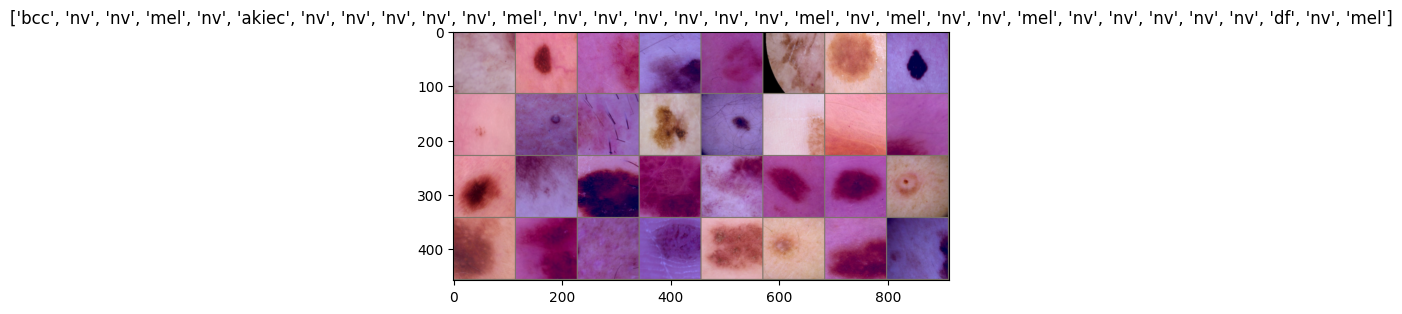

In [55]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders[TRAIN_KEY]))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model

Now, let's write a general function to train a model. Here, we will
illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from
``torch.optim.lr_scheduler``.



In [56]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Store metrics for visualization
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Save metrics
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history


In [67]:
#Visualising the performance
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14,6))

    # Loss graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    # Accuracy graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label="Train Accuracy")
    plt.plot(epochs, history['val_acc'], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    plt.show()


### Visualizing the model predictions

Generic function to display predictions for a few images




In [58]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Saving and loading

In [59]:
def save_checkpoint(save_path: str, model: torch.nn.Module, epoch=-1, optimizer=None, criterion=None):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else {},
            'loss': criterion,
        }
        torch.save(checkpoint, save_path)

In [60]:
def move_dict_parameters_to_device(state_dict: dict, device: str) -> dict:
      for parameter in state_dict.values():
        if isinstance(parameter, torch.Tensor):
          parameter.to(device)
      return state_dict

def load_model(save_path: str, model: torch.nn.Module, optimizer: torch.nn.Module=None, device: str="cpu") -> torch.nn.Module:
        checkpoint_dict = torch.load(save_path)
        model.load_state_dict(checkpoint_dict["model_state_dict"])
        if optimizer is not None:
            state_dict = checkpoint_dict["optimizer_state_dict"]
            state_dict = move_dict_parameters_to_device(state_dict, device)
            optimizer.load_state_dict(state_dict)
        model.to(device)
        model.eval()
        return model

In [ ]:
#defining plotting confusion matrix to check for accuracy
def plot_confusion_matrix(model, dataloader, device, class_names):
    """
    Plots a confusion matrix for the given model and dataloader.
    """
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


## Finetuning the convnet

Load a pretrained model and reset final fully connected layer.




In [ ]:
model_ft = models.efficientnet_b0(pretrained=True)
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9,weight_decay=1e-4)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.OneCycleLR(optimizer_ft, max_lr=0.01, steps_per_epoch=len(dataloaders['train']),epochs=30)

### Train and evaluate


In [63]:
#Adding a test evaluation Function
def evaluate(model, dataloader):
    model.eval()
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()

    return running_corrects / len(dataloader.dataset)





In [ ]:
epochs=30
model_ft, history = train_model(
    model_ft,
    criterion,
    optimizer_ft,
    exp_lr_scheduler,
    num_epochs=epochs
)

Epoch 0/29
----------
train Loss: 1.2704 Acc: 0.6766
val Loss: 1.1567 Acc: 0.7101

Epoch 1/29
----------
train Loss: 1.0394 Acc: 0.7455
val Loss: 1.0923 Acc: 0.7218

Epoch 2/29
----------
train Loss: 0.9788 Acc: 0.7708
val Loss: 1.0594 Acc: 0.7493

Epoch 3/29
----------
train Loss: 0.9418 Acc: 0.7901
val Loss: 1.0174 Acc: 0.7542

Epoch 4/29
----------
train Loss: 0.9268 Acc: 0.7939
val Loss: 1.0085 Acc: 0.7728

Epoch 5/29
----------
train Loss: 0.9059 Acc: 0.8045
val Loss: 0.9972 Acc: 0.7806

Epoch 6/29
----------
train Loss: 0.8888 Acc: 0.8067
val Loss: 0.9774 Acc: 0.7845

Epoch 7/29
----------
train Loss: 0.8806 Acc: 0.8130
val Loss: 0.9603 Acc: 0.7855

Epoch 8/29
----------
train Loss: 0.8744 Acc: 0.8187
val Loss: 0.9627 Acc: 0.7914

Epoch 9/29
----------
train Loss: 0.8605 Acc: 0.8190
val Loss: 0.9499 Acc: 0.7933

Epoch 10/29
----------
train Loss: 0.8461 Acc: 0.8295
val Loss: 0.9543 Acc: 0.7914

Epoch 11/29
----------
train Loss: 0.8386 Acc: 0.8276
val Loss: 0.9496 Acc: 0.7953

Ep

In [72]:
save_checkpoint("checkpoint.pth", model_ft, epochs, optimizer_ft, criterion)

In [73]:
#testing the accuracy on the test data
test_acc = evaluate(model_ft, dataloaders["test"])
print("Test Accuracy:", test_acc)

Test Accuracy: 0.5657142857142857


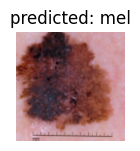

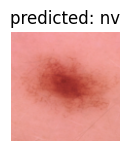

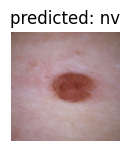

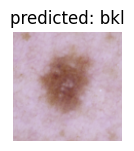

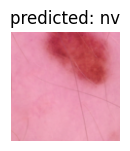

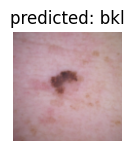

In [74]:
visualize_model(model_ft)

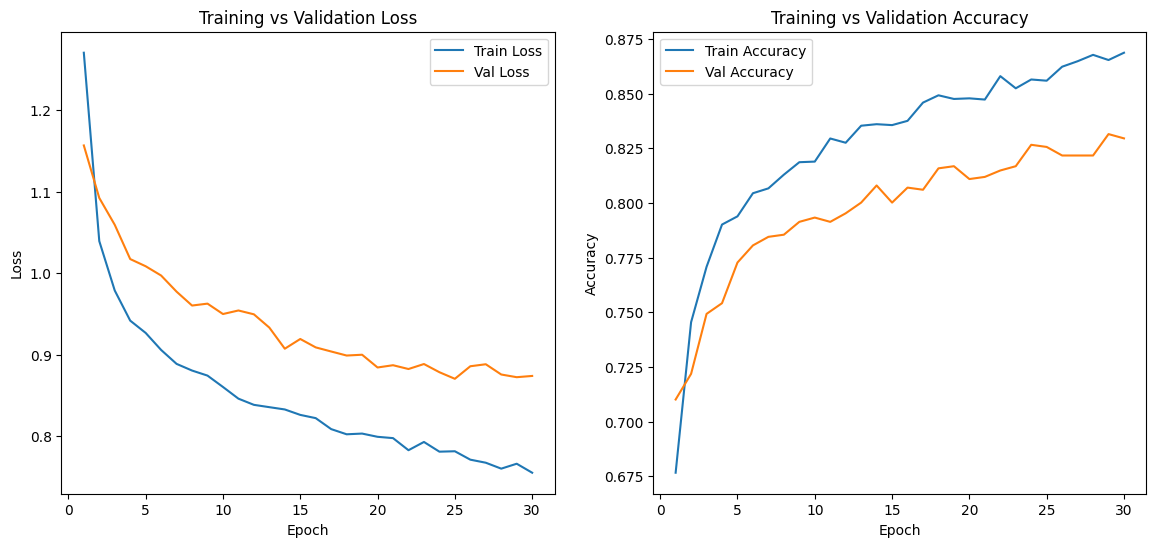

In [76]:
plot_training_history(history)

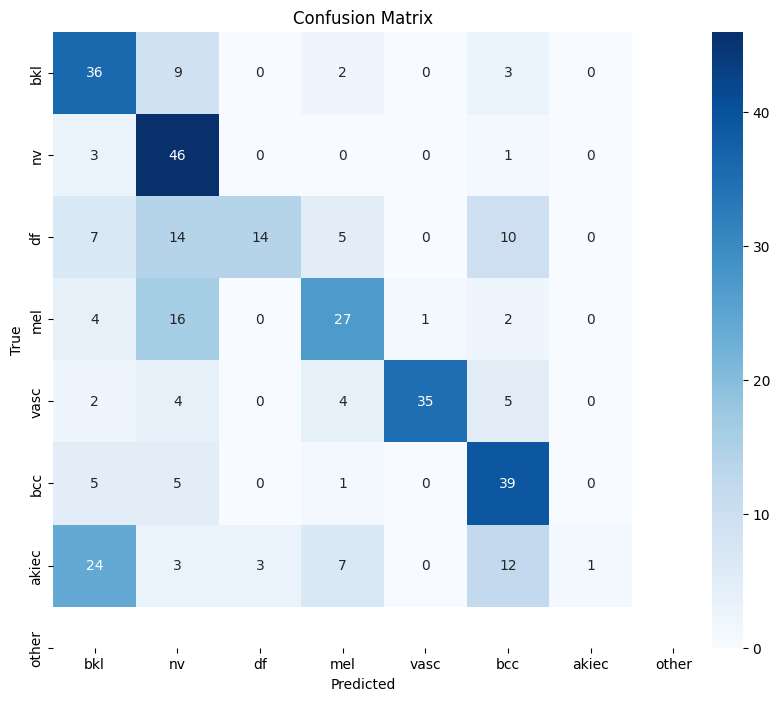

In [80]:


plot_confusion_matrix(model_ft, dataloaders["test"], device, class_names)
